In [5]:
# Import pandas for data loading, cleaning, and table-like DataFrame operations
import pandas as pd

# Import NumPy for numerical operations and array handling
import numpy as np

# Split dataset into training and testing sets
# cross_val_score evaluates model performance across multiple folds
# GridSearchCV searches for the best model parameters automatically
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Random Forest Classifier used to predict Titanic survival
from sklearn.ensemble import RandomForestClassifier

# Metrics used to evaluate model performance
# accuracy_score: overall prediction accuracy
# confusion_matrix: correct vs incorrect predictions by class
# classification_report: precision, recall, f1-score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Load the Titanic dataset from the CSV file into a pandas DataFrame
# 'df' is the main table that will store and manage our dataset
df = pd.read_csv("train.csv")

# Display the first 5 rows of the dataset
# Useful for previewing the data structure, columns, and sample values
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Fill missing values in Age column using the median age
# Median is used because it is less affected by outliers than mean
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing values in Embarked column using the most frequent value (mode)
# This assumes most passengers boarded from the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing values in Fare column using median fare value
# Ensures no missing numeric values remain before model training
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop Cabin column because it has too many missing values
# Also difficult to use meaningfully in basic machine learning models
df = df.drop(columns=['Cabin'])

In [9]:
# Family features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Extract Title from Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Rare')

In [10]:
# Convert Sex column into numeric values for machine learning
# male = 0, female = 1
# ML models cannot directly work with text labels
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode categorical variables (Embarked and Title)
# This converts categories into binary columns (0/1 format)
# drop_first=True avoids duplicate information (multicollinearity)
df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

In [11]:
# Define feature variables (X) by removing target and irrelevant columns
# Survived is the target we want to predict, so it is excluded
# Name, Ticket, and PassengerId are not useful for prediction in this model
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])

# Define target variable (y)
# This is the column the model will learn to predict (0 = did not survive, 1 = survived)
y = df['Survived']

In [12]:
# Initialize a baseline Random Forest model
# random_state ensures results are reproducible
base_model = RandomForestClassifier(random_state=42)

# Perform 5-fold cross-validation
# The dataset is split into 5 parts; model trains on 4 and validates on 1 repeatedly
# This gives a more reliable performance estimate than a single train/test split
scores = cross_val_score(base_model, X, y, cv=5)

# Print accuracy for each fold
print("Fold Scores:", scores)

# Print average accuracy across all folds
# This represents overall model performance more reliably
print("Mean Accuracy:", scores.mean())

Fold Scores: [0.79329609 0.79213483 0.84269663 0.75842697 0.81460674]
Mean Accuracy: 0.8002322515849603


In [13]:
# Define a grid of hyperparameters to search for the best Random Forest model
# n_estimators: number of trees in the forest
# max_depth: maximum depth of each tree
# min_samples_split: minimum samples required to split a node
# min_samples_leaf: minimum samples required at a leaf node
# max_features: number of features considered when splitting a node
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

# Initialize GridSearchCV to automatically find the best hyperparameters
# cv=5 means 5-fold cross-validation
# scoring='accuracy' evaluates models based on accuracy
# n_jobs=-1 uses all CPU cores for faster computation
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV on the full dataset to find the best model parameters
grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [14]:
# Display the best cross-validation accuracy achieved during GridSearchCV
# This represents the highest average performance across all parameter combinations tested
print("Best Score:", grid.best_score_)

# Display the best combination of hyperparameters found
# These are the settings that produced the highest accuracy
print("Best Params:", grid.best_params_)

Best Score: 0.8316364321134893
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}


In [15]:
# Split the dataset into training and testing sets
# 80% of data is used for training, 20% is used for testing
# random_state ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrieve the best model found by GridSearchCV
# This model has the best combination of hyperparameters
best_model = grid.best_estimator_

# Train the best model on the training data
best_model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate model performance using accuracy on unseen test data
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8435754189944135


In [16]:
# Confusion matrix shows the number of correct and incorrect predictions
# Format:
# [[True Negatives, False Positives],
#  [False Negatives, True Positives]]
print(confusion_matrix(y_test, y_pred))

# Classification report gives detailed evaluation metrics:
# - Precision: how many predicted positives were actually correct
# - Recall: how many actual positives were correctly identified
# - F1-score: balance between precision and recall
# - Support: number of samples in each class
print(classification_report(y_test, y_pred))

[[93 12]
 [16 58]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



In [17]:
# Get feature importance from the trained Random Forest model
# This shows how much each feature contributes to predictions
importance = pd.Series(best_model.feature_importances_, index=X.columns)

# Sort features by importance in descending order
# Helps identify which features influence survival most
print(importance.sort_values(ascending=False))

Fare          0.192152
Sex           0.162762
Title_Mr      0.159409
Age           0.146077
Pclass        0.090508
FamilySize    0.053557
Title_Mrs     0.047968
Title_Miss    0.035124
SibSp         0.034385
Parch         0.025529
Embarked_S    0.022911
IsAlone       0.011567
Title_Rare    0.009245
Embarked_Q    0.008807
dtype: float64


In [20]:
# Import Matplotlib for plotting graphs and visualizations
# It is used to create charts like line plots, bar charts, histograms, etc.
import matplotlib.pyplot as plt

# Import Seaborn for advanced statistical data visualization
# Built on top of Matplotlib, provides cleaner and more attractive plots
import seaborn as sns

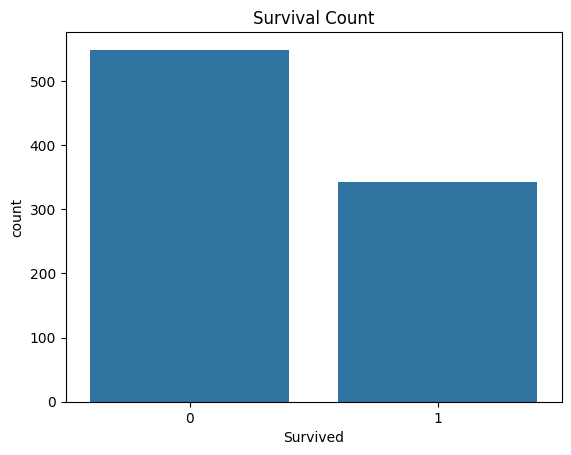

In [21]:
# Countplot shows the number of passengers who survived vs those who did not
# 0 = Did not survive, 1 = Survived
# This helps understand class imbalance in the dataset
sns.countplot(x='Survived', data=df)

# Add a title to the plot for clarity
plt.title("Survival Count")

# Display the plot
plt.show()

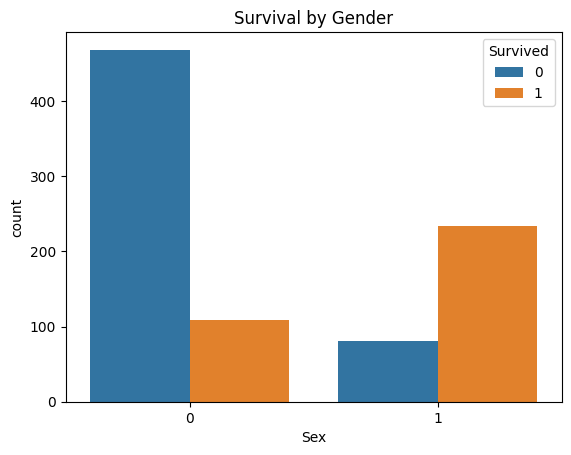

In [22]:
# Countplot showing survival distribution based on gender
# x-axis: Sex (0 = male, 1 = female)
# hue: Survived (shows survival comparison within each gender)
# This helps visualize how gender influenced survival chances
sns.countplot(x='Sex', hue='Survived', data=df)

# Add title for better interpretation of the graph
plt.title("Survival by Gender")

# Display the plot
plt.show()

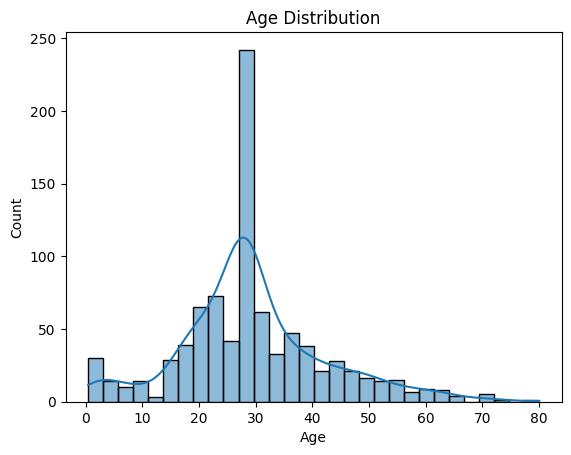

In [23]:
# Histogram showing the distribution of passenger ages
# bins=30 divides age range into 30 intervals for better detail
# kde=True adds a smooth curve showing the probability distribution
sns.histplot(df['Age'], bins=30, kde=True)

# Add title to describe the visualization
plt.title("Age Distribution")

# Display the plot
plt.show()

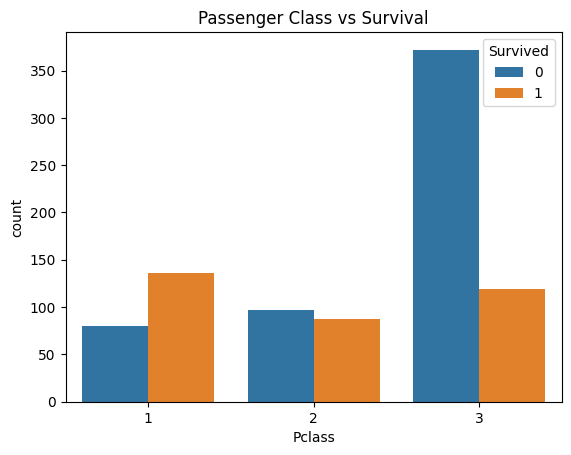

In [24]:
# Countplot showing survival distribution across passenger classes
# x-axis: Pclass (1 = First class, 2 = Second class, 3 = Third class)
# hue: Survived (compares survival within each class)
# Helps understand how socio-economic status influenced survival chances
sns.countplot(x='Pclass', hue='Survived', data=df)

# Add title for clarity
plt.title("Passenger Class vs Survival")

# Display the plot
plt.show()

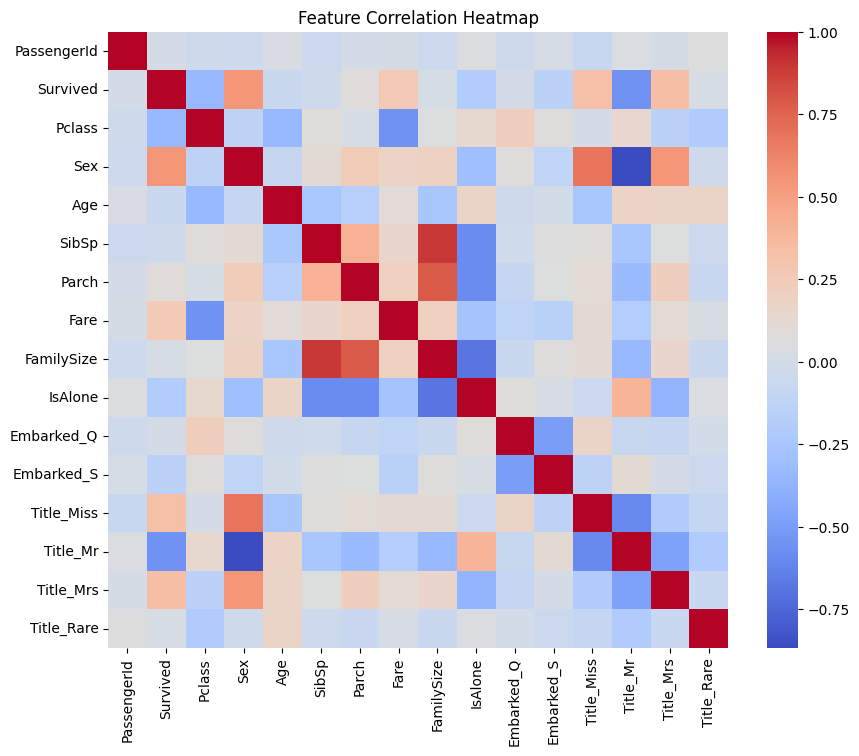

In [25]:
# Set the figure size to make the heatmap larger and easier to read
plt.figure(figsize=(10, 8))

# Compute correlation matrix for all numeric features in the dataset
# Heatmap visually shows relationships between variables
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')

# Add title to describe the visualization
plt.title("Feature Correlation Heatmap")

# Display the heatmap
plt.show()

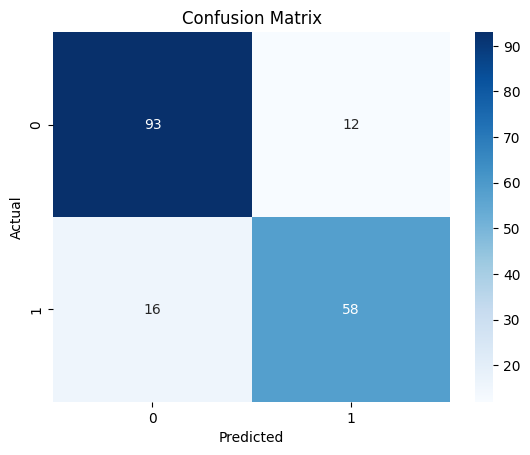

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

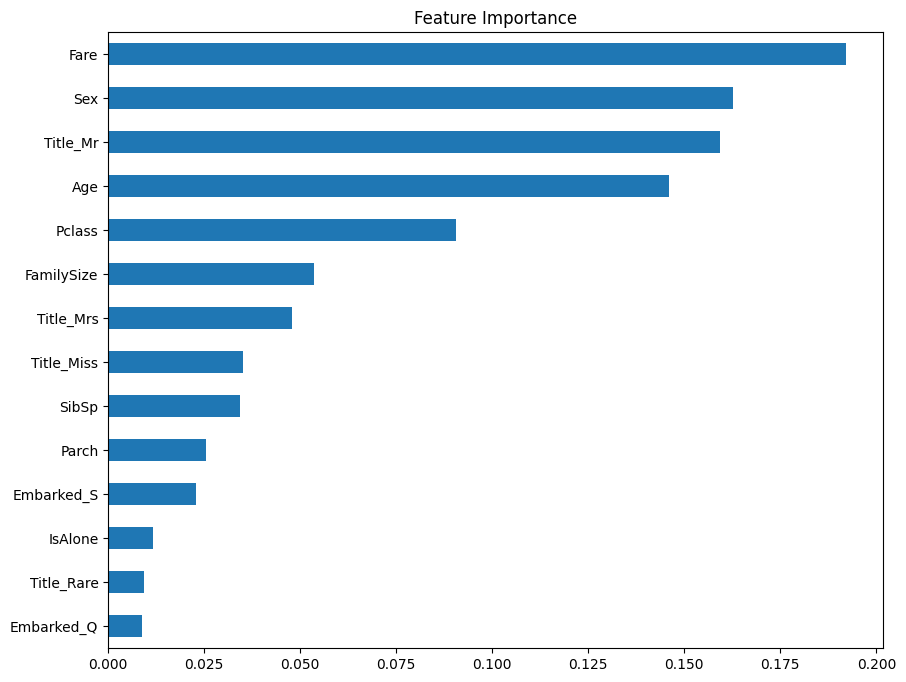

In [27]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,8))
plt.title("Feature Importance")
plt.show()